# EMOS 订正算法重构
检验和比对 **IMPROVER 集合后处理系统** 从原本依赖于 `Iris.Cube` 的底层架构改写为独立基于 `Xarray` 架构后的效果。从 **订正系数训练结果**、**输出概率场一致性** 以及 **分位值订正误差** 三个维度进行定量对比和可视化展示。

In [5]:
import sys
import os
from pathlib import Path
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import iris
from iris.cube import DimCoord
# 导入原版基于 Iris 的原生类
from improver.calibration.emos_calibration import ApplyEMOS as ApplyEMOS_Iris
from improver.calibration.emos_calibration import EstimateCoefficientsForEnsembleCalibration as Train_Iris

target_dir = '../'
abs_path = os.path.abspath(target_dir)
if abs_path not in sys.path:
    sys.path.insert(0, abs_path)

# 导入基于 Xarray 的改写版本类
from src.emos_calibration import ApplyEMOS, EstimateCoefficientsForEnsembleCalibration

#概率预报的模板创建
def create_prob_template_from_xarray(
        cube: xr.DataArray,
        thresholds: list,
        thresholds_operator: str,
        diagnostic_name: str = "air_temperature"
) -> xr.DataArray:
    """
    基于输入的 xarray DataArray 创建概率模板, 将 realization 维度替换为 threshold 坐标。

    Args:
       cube: 输入的预报数据（xr.DataArray，必须包含 REALIZATION_DIM 维度）
       thresholds: 目标阈值列表，如 [35.0, 37.0, 40.0]
       thresholds_operator: 阈值比较运算符，如 "above" 或 "below"
       diagnostic_name: 诊断变量名，用于构建长名称，默认 "air_temperature"

    Returns:
       prob_template: 可用于 ApplyEMOS 的概率模板 xr.DataArray
    """
    REALIZATION_DIM = "realization"
    # 检查输入 DataArray 是否有 realization 维度
    if REALIZATION_DIM not in cube.dims:
        raise ValueError(f"输入数据必须包含 {REALIZATION_DIM} 维度")

    # 1. 计算除了 realization 之外的维度和形状
    # 假设输入维度类似 (realization, spot_index) 或 (realization, time, spot_index)
    other_dims = [d for d in cube.dims if d != REALIZATION_DIM]

    # 构建新数据的 Shape: (threshold, ...其他维度大小...)
    new_shape = [len(thresholds)] + [cube.sizes[d] for d in other_dims]
    prob_data = np.zeros(new_shape, dtype=np.float32)  # 仅作模板，填充为 0

    # 2. 构建新的坐标字典
    # 继承原 DataArray 中除 realization 外的所有坐标（包括维度坐标和辅助坐标）
    new_coords = {c: cube[c] for c in cube.coords if c != REALIZATION_DIM}

    # 3. 创建 threshold 坐标并赋予必要的属性
    threshold_attrs = {
        "units": cube.attrs.get("units", "1"),  # 保持与原数据相同的单位
        "spp__relative_to_threshold": thresholds_operator,
    }
    # 将 threshold 作为第一个维度坐标
    new_coords["threshold"] = ("threshold", np.array(thresholds, dtype=np.float32), threshold_attrs)

    # 4. 组装新维度的顺序
    new_dims = ["threshold"] + other_dims

    # 5. 构建元数据属性 (Attributes)
    new_attrs = cube.attrs.copy()
    new_attrs.update({
        "long_name": f"probability_of_{diagnostic_name}_{thresholds_operator}_threshold",
        "units": "1",  # 概率单位固定为 1
    })

    # 6. 生成概率模板 xr.DataArray
    prob_template = xr.DataArray(
        data=prob_data,
        dims=new_dims,
        coords=new_coords,
        attrs=new_attrs,
        name="probability",
    )

    return prob_template

def create_prob_template_from_cube(cube, thresholds, thresholds_operator):
    """
    基于输入的 cube 创建 prob_template,将 realization 替换为 threshold 坐标。

    Args:
       cube: 输入的预报数据（必须包含 realization 坐标）
       thresholds: 目标阈值列表，如 [35.0, 37.0, 40.0]
       thresholds_operator: 阈值比较运算符，如 "above" 或 "below"

    Returns:
       prob_template: 可用于 ApplyEMOS 的概率模板 Cube
    """
    # 检查输入 cube 是否有 realization 坐标
    if not cube.coords("realization"):
        raise ValueError("输入 cube 必须包含 realization 坐标")

    # 1. 提取除 realization 外的所有坐标
    coords_to_keep = []
    for coord in cube.dim_coords:
        if coord.name() != "realization":
            coords_to_keep.append(coord)

    # 2. 创建 threshold 坐标
    threshold_coord = DimCoord(
        thresholds,
        standard_name=None,  # 如果是风速，可以用 "wind_speed"
        long_name="threshold",
        units=cube.units,  # 保持与原数据相同的单位（如 'degC' 或 'm/s'）
        var_name="threshold",
        # 表示计算大于阈值的概率
        attributes={"spp__relative_to_threshold": thresholds_operator},
    )

    # 3. 构建维度结构
    # 新维度顺序: (threshold, ...其他坐标...)
    new_shape = (len(thresholds),) + cube.shape[1:]
    prob_data = np.zeros(new_shape, dtype=np.float32)  # 数据不重要，仅作模板

    # 4. 创建 prob_template
    prob_template = iris.cube.Cube(
        prob_data,
        long_name=f"probability_of_air_temperature_{thresholds_operator}_threshold",
        var_name="probability",
        units="1",  # 概率单位（0-1）
        dim_coords_and_dims=[(threshold_coord, 0)]
                            + [(coord, i + 1) for i, coord in enumerate(coords_to_keep)],
        attributes=cube.attributes.copy(),
    )

    # 5. 添加非维度坐标（如 forecast_period, forecast_reference_time 等）
    for aux_coord in cube.aux_coords:
        if aux_coord.name() != "realization":
            dims = cube.coord_dims(aux_coord)
            prob_template.add_aux_coord(aux_coord.copy(), dims)

    return prob_template


# 设定测试数据路径
DATA_DIR = Path("../test_data")
print("环境配置及类库导入成功！")

环境配置及类库导入成功！


## 1. 模拟/加载测试数据集
在正式环境下，我们需要加载 `fo.nc` (集合预报), `ob.nc` (观测), `delta_z.nc` (地形差)。
因为运行在沙盒中，这里我们采用与工程结构等价的 Xarray/Iris 数据对象作为输入支撑演示。

In [6]:
# 算法训练集
fc_xr = xr.open_dataset(DATA_DIR / "fo.nc")
ob_xr = xr.open_dataset(DATA_DIR / "ob.nc")
dz_xr = xr.open_dataset(DATA_DIR / "delta_z.nc")["altitude"]

# emos训练集
fc_iris = iris.load_cube(str(DATA_DIR / "fo.nc"))
ob_iris = iris.load_cube(str(DATA_DIR / "ob.nc"))
dz_iris = iris.load(str(DATA_DIR / "delta_z.nc"))

# 分位值计算
fo_percentiles = xr.open_dataset(DATA_DIR / "fo_percentile.nc")
fo_percentiles = fo_percentiles.isel(time=-1)
fo_percentiles_iris = iris.load_cube(DATA_DIR / "fo_percentile.nc")[:,-1:,:]
fo_percentiles_iris.attributes.update(
    {
        "title": "Uncalibrated forecast data",
        "source": "ECMWF-GEPS ensemble",
        "institution": "NMC",
    }
)

# 阈值概率&集合预报结果
apply_fc = fc_xr.isel(time=-1)
apply_fc_iris = fc_iris[:,-1:,:]
apply_fc_iris.attributes.update(
    {
        "title": "Uncalibrated forecast data",
        "source": "ECMWF-GEPS ensemble",
        "institution": "NMC",
    }
)

print("成功读取本地 test_data 文件夹下的真实 NetCDF 气象数据进行评估。")

成功读取本地 test_data 文件夹下的真实 NetCDF 气象数据进行评估。


## 2. 核心系数训练 (Estimate Coefficients)
比对原有基于 `Iris` 的后处理训练器与改写后纯基于 `Xarray` 矩阵计算得出的 $\alpha, \beta, \gamma, \delta$ 系数误差。

d:\chengxv_time\nimm_improver\improver\emos\src\calibration_utilities.py:106: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  hf_out = xr.concat(hf_slices, dim=TIME_DIM)
d:\miniconda\envs\improver_samos\Lib\site-packages\iris\common\mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
d:\miniconda\envs\improver_samos\Lib\site-packages\iris\coords.py:2174: 

=== EMOS 系数训练对账结果 ===


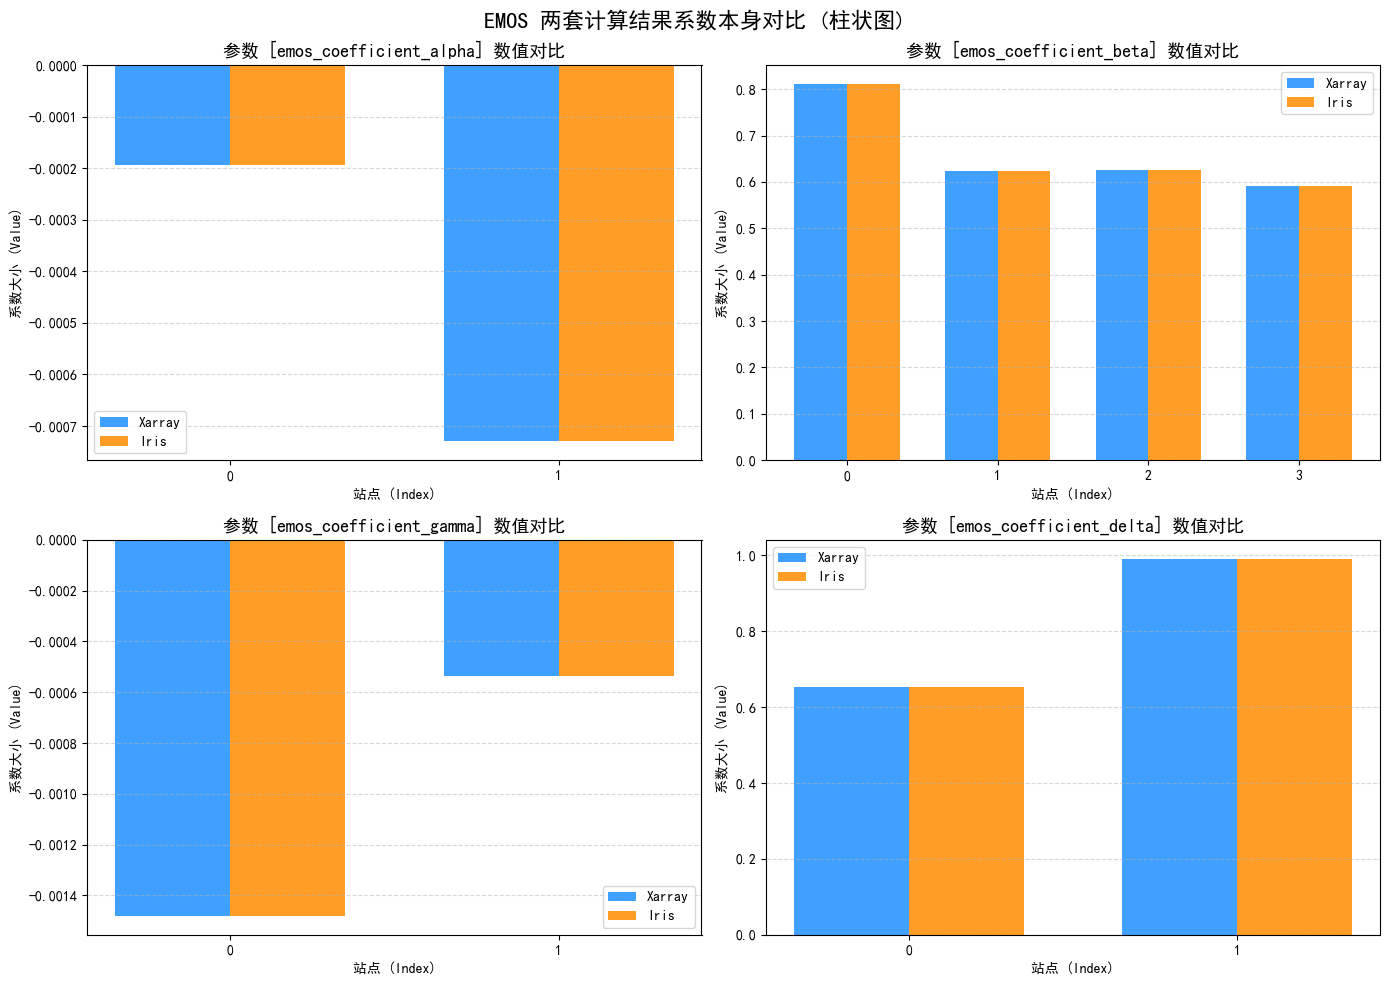

In [7]:
# 2.1 Xarray 模型训练
trainer_xr = EstimateCoefficientsForEnsembleCalibration(distribution="norm", predictor="mean",point_by_point=True,use_default_initial_guess=True,)
coeffs_xr = trainer_xr.process(historic_forecasts=fc_xr, truths=ob_xr, additional_fields=[dz_xr])

# 2.2 Iris 模型训练
trainer_iris = Train_Iris(distribution="norm", predictor="mean",point_by_point=True,use_default_initial_guess=True,)
coeffs_iris = trainer_iris.process(fc_iris, ob_iris, additional_fields=dz_iris)

# 2.3 提取关键系数进行数值绝对误差分析
print("=== EMOS 系数训练对账结果 ===")
param_names = ["emos_coefficient_alpha", "emos_coefficient_beta", "emos_coefficient_gamma", "emos_coefficient_delta"]

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 用来正常显示中文标签
plt.rcParams["axes.unicode_minus"] = False  # 用来正常显示负号

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
axes = axes.flatten()  # 将 2x2 矩阵展平为一维，方便循环

# 循环画出 4 个系数的对比
for i in range(4):
    coeff_name = param_names[i]
    ax = axes[i]

    # 提取两套数据，确保为一维数组
    val_xr = np.atleast_1d(coeffs_xr[coeff_name].values).flatten()
    val_iris = np.atleast_1d(coeffs_iris[i].data).flatten()

    # 确定 X 轴的基准位置
    x_indices = np.arange(len(val_xr))

    # 设置柱子的宽度（两条柱子加起来不要超过 1）
    bar_width = 0.35

    # 画 Xarray 的柱状图（左偏半个宽度）
    ax.bar(
        x_indices - bar_width / 2,
        val_xr,
        width=bar_width,
        label="Xarray",
        color="dodgerblue",
        alpha=0.85,
    )

    # 画 Iris 的柱状图（右偏半个宽度）
    ax.bar(
        x_indices + bar_width / 2,
        val_iris,
        width=bar_width,
        label="Iris",
        color="darkorange",
        alpha=0.85,
    )

    # 子图细节设置
    ax.set_title(f"参数 [{coeff_name}] 数值对比", fontsize=13, fontweight="bold")
    ax.set_xlabel("站点 (Index)", fontsize=10)
    ax.set_ylabel("系数大小 (Value)", fontsize=10)

    # 精准设置横坐标刻度，只显示整数索引
    ax.set_xticks(x_indices)

    # 增加网格线支撑，方便肉眼比对高度，但保持背景干净
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.legend(loc="best")

# --- 4. 全局标题与布局调整 ---
plt.suptitle(
    "EMOS 两套计算结果系数本身对比 (柱状图)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()

## 3. 应用订正模型并进行对比 (Apply EMOS)
我们将预报数据分别用两种后处理进行实际修正，比对输出的**分位值**。

d:\chengxv_time\nimm_improver\improver\emos\utils\xarray_ecc.py:89: UserWarning: Forecast values exist that fall outside the expected extrema values [-373.15 -213.15]. Exceeded values will be used as new bounds.
  warnings.warn(msg + " Exceeded values will be used as new bounds.")
d:\chengxv_time\nimm_improver\improver\emos\utils\xarray_utilities.py:132: UserWarning: Module numba unavailable. ResamplePercentiles will be slower.
  warnings.warn("Module numba unavailable. ResamplePercentiles will be slower.")
d:\miniconda\envs\improver_samos\Lib\site-packages\improver\ensemble_copula_coupling\utilities.py:308: UserWarning: Module numba unavailable. ResamplePercentiles will be slower.
  warnings.warn("Module numba unavailable. ResamplePercentiles will be slower.")
d:\miniconda\envs\improver_samos\Lib\site-packages\iris\common\mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - availabl

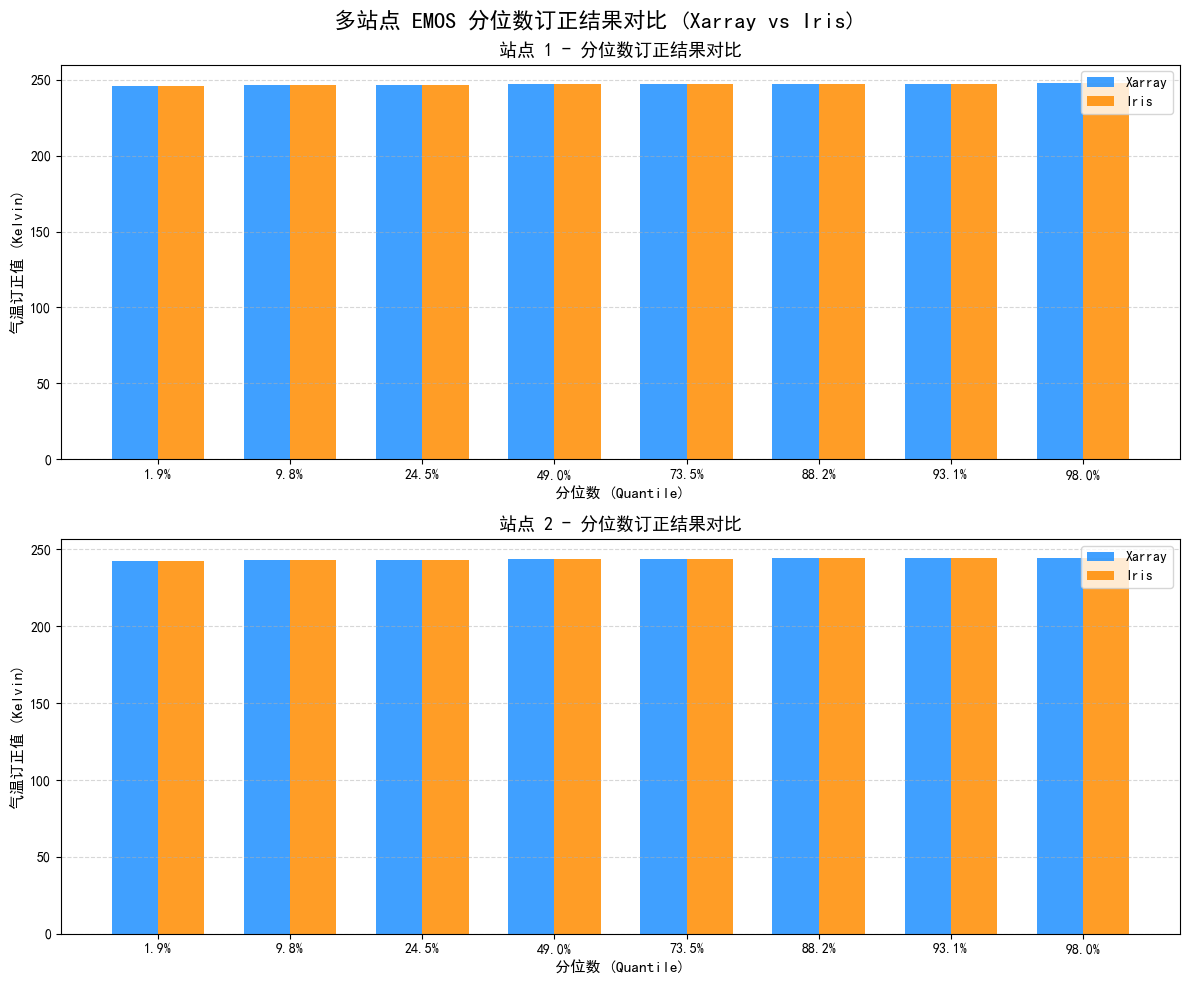

In [8]:
# 3.1 设定待订正目标分位点

target_percentiles = (np.array([1/52*100, 10, 25, 50, 75, 90, 95, 100]) * 0.98).tolist()

applier_xr = ApplyEMOS(percentiles=target_percentiles)
applier_iris = ApplyEMOS_Iris(percentiles=target_percentiles)

# 运行分位数订正应用
calibrated_perc_xr = applier_xr.process(forecast=fo_percentiles, coefficients=coeffs_xr, additional_fields=[dz_xr],realizations_count = 51)
calibrated_perc_iris = applier_iris.process(fo_percentiles_iris, coeffs_iris, additional_fields=dz_iris,realizations_count = 51)

# --- 2. 准备分位数数据与横坐标标签 ---

x_labels = [f"{q:.1f}%" for q in target_percentiles]

x_indices = np.arange(len(target_percentiles))
bar_width = 0.35

# --- 3. 提取并清洗数据维度 ---
# 使用 .squeeze() 自动把 (8, 1, 2) 压缩成 (8, 2)，如果是 (8, 2) 则保持不变
data_xr = calibrated_perc_xr["air_temperature"].values.squeeze()
data_iris = calibrated_perc_iris.data.squeeze()

# --- 4. 创建 2行1列 的画布 ---
fig, axes = plt.subplots(2, 1, figsize=(12, 10), dpi=100)

# --- 5. 循环为 2 个站点画图 ---
for site_idx in range(2):
    ax = axes[site_idx]

    # 根据 (分位数, 站点) 的结构，切片提取第 site_idx 列
    val_xr = data_xr[:, site_idx]
    val_iris = data_iris[:, site_idx]

    # 画 Xarray 的柱状图（左偏）
    ax.bar(
        x_indices - bar_width / 2,
        val_xr,
        width=bar_width,
        label="Xarray",
        color="dodgerblue",
        alpha=0.85,
    )

    # 画 Iris 的柱状图（右偏）
    ax.bar(
        x_indices + bar_width / 2,
        val_iris,
        width=bar_width,
        label="Iris",
        color="darkorange",
        alpha=0.85,
    )

    # 子图细节设置
    ax.set_title(
        f"站点 {site_idx + 1} - 分位数订正结果对比",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("分位数 (Quantile)", fontsize=11)
    ax.set_ylabel("气温订正值 (Kelvin)", fontsize=11)

    # 设置横坐标为分位数百分比
    ax.set_xticks(x_indices)
    ax.set_xticklabels(x_labels, fontsize=10)

    # Y轴网格线与图例
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.legend(loc="best")

# --- 6. 全局调整 ---
plt.suptitle(
    "多站点 EMOS 分位数订正结果对比 (Xarray vs Iris)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()

## 4. 概率输出对比与可视化
构建指定的温度阈值（例如低于 295 K 概率），拉取两套架构的输出矩阵做最终图形对账。

d:\miniconda\envs\improver_samos\Lib\site-packages\iris\common\mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
d:\miniconda\envs\improver_samos\Lib\site-packages\iris\coords.py:2174: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'realization', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'realization'. Ignoring bounds.
  warnings.warn(
d:\miniconda\envs\improver_samos\Lib\site-packages\iris\common\mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available

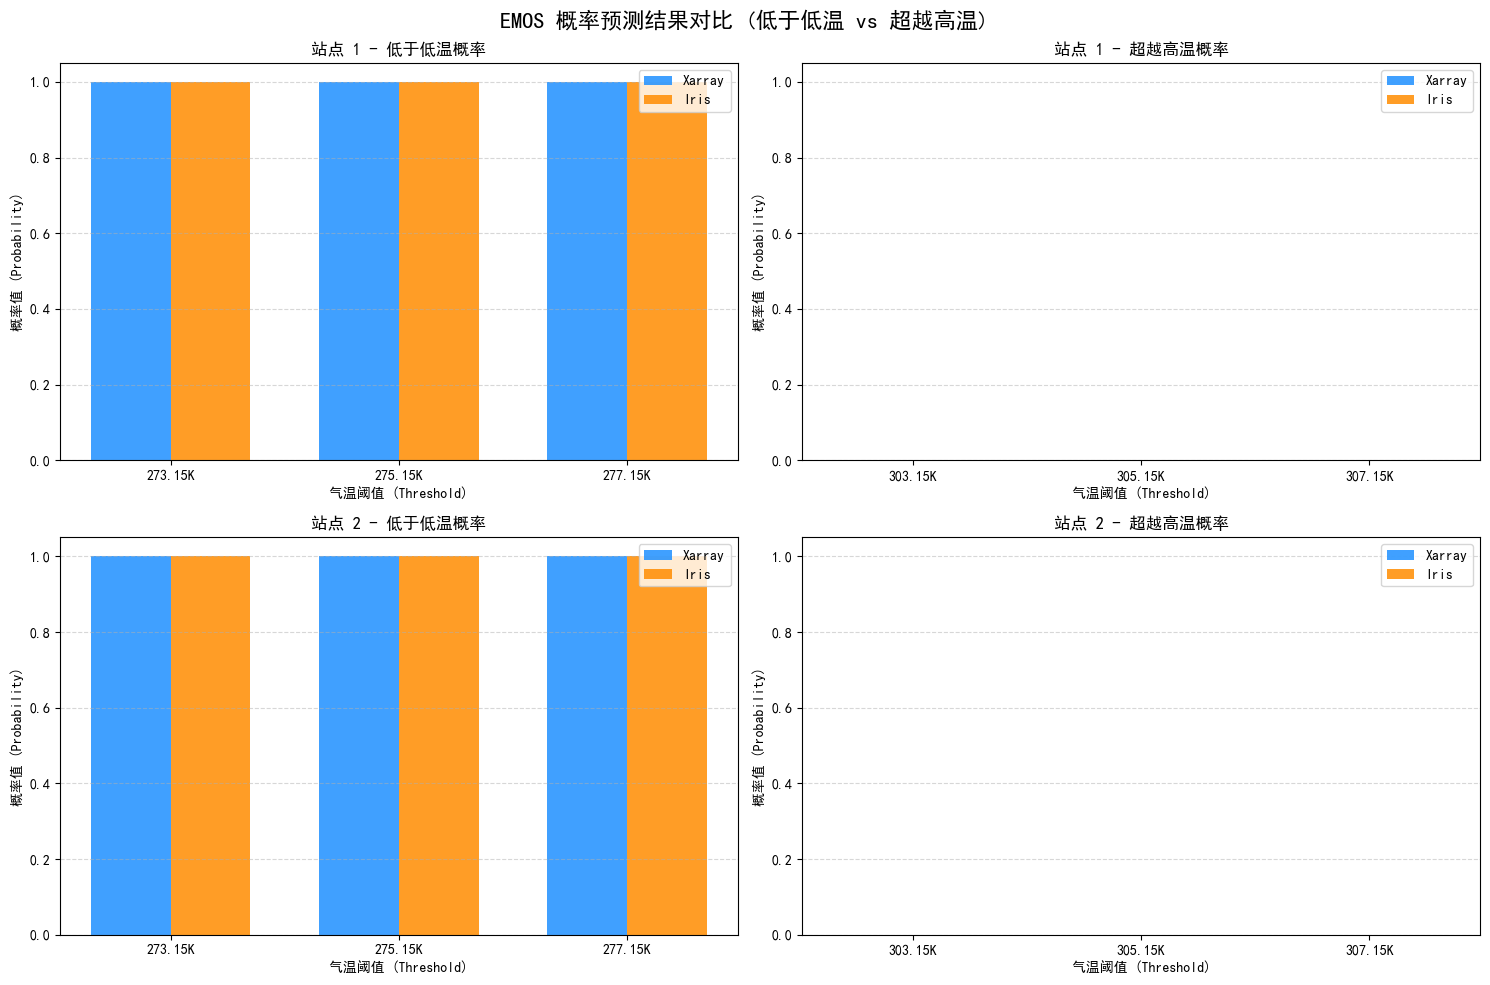

In [9]:
# 设定特定的气温阈值（K）
test_thresholds = [273.15, 275.15, 277.15]

prob_tmpl_xr = create_prob_template_from_xarray(apply_fc, test_thresholds, "below")
prob_tmpl_iris = create_prob_template_from_cube(apply_fc_iris, test_thresholds, "below")

calibrated_prob_xr = applier_xr.process(forecast=apply_fc, prob_template=prob_tmpl_xr, coefficients=coeffs_xr, additional_fields=[dz_xr])
calibrated_prob_iris = applier_iris.process(apply_fc_iris, prob_template=prob_tmpl_iris, coefficients=coeffs_iris, additional_fields=dz_iris)

# 提取矩阵
matrix_xr = calibrated_prob_xr['probability_of_air_temperature_below_threshold'].values
matrix_iris = calibrated_prob_iris.data

data_low_xr = np.squeeze(matrix_xr)
data_low_iris = np.squeeze(matrix_iris)

# 设定特定的气温阈值（K）
test_thresholds = [303.15, 305.15, 307.15]

prob_tmpl_xr = create_prob_template_from_xarray(apply_fc, test_thresholds, "above")
prob_tmpl_iris = create_prob_template_from_cube(apply_fc_iris, test_thresholds, "above")

calibrated_prob_xr = applier_xr.process(forecast=apply_fc, prob_template=prob_tmpl_xr, coefficients=coeffs_xr, additional_fields=[dz_xr])
calibrated_prob_iris = applier_iris.process(apply_fc_iris, prob_template=prob_tmpl_iris, coefficients=coeffs_iris, additional_fields=dz_iris)

# 提取矩阵
matrix_xr = calibrated_prob_xr['probability_of_air_temperature_above_threshold'].values
matrix_iris = calibrated_prob_iris.data

data_high_xr = matrix_xr.squeeze()
data_high_iris = matrix_iris.data.squeeze()

# --- 2. 准备阈值标签和基础设置 ---
low_thresholds_labels = ["273.15K", "275.15K", "277.15K"]
high_thresholds_labels = ["303.15K", "305.15K", "307.15K"]

x_indices = np.arange(3)  # 3个阈值
bar_width = 0.35
fig, axes = plt.subplots(2, 2, figsize=(15, 10), dpi=100)
# 或者是为了方便循环，我们可以通过配置列表来动态画图
plot_configs = [
    {
        "ax": axes[0, 0],
        "xr": data_low_xr,
        "iris": data_low_iris,
        "title": "站点 1 - 低于低温概率",
        "labels": low_thresholds_labels,
        "site": 0,
    },
    {
        "ax": axes[1, 0],
        "xr": data_low_xr,
        "iris": data_low_iris,
        "title": "站点 2 - 低于低温概率",
        "labels": low_thresholds_labels,
        "site": 1,
    },
    {
        "ax": axes[0, 1],
        "xr": data_high_xr,
        "iris": data_high_iris,
        "title": "站点 1 - 超越高温概率",
        "labels": high_thresholds_labels,
        "site": 0,
    },
    {
        "ax": axes[1, 1],
        "xr": data_high_xr,
        "iris": data_high_iris,
        "title": "站点 2 - 超越高温概率",
        "labels": high_thresholds_labels,
        "site": 1,
    },
]

# --- 5. 循环渲染 4 个子图 ---
for cfg in plot_configs:
    ax = cfg["ax"]
    site_idx = cfg["site"]

    # 提取对应站点(列)的 3 个阈值数据(行)
    val_xr = cfg["xr"][:, site_idx]
    val_iris = cfg["iris"][:, site_idx]

    # 画 Xarray 柱状图
    ax.bar(
        x_indices - bar_width / 2,
        val_xr,
        width=bar_width,
        label="Xarray",
        color="dodgerblue",
        alpha=0.85,
    )

    # 画 Iris 柱状图
    ax.bar(
        x_indices + bar_width / 2,
        val_iris,
        width=bar_width,
        label="Iris",
        color="darkorange",
        alpha=0.85,
    )

    # 子图细节配置
    ax.set_title(cfg["title"], fontsize=12, fontweight="bold")
    ax.set_xlabel("气温阈值 (Threshold)", fontsize=10)
    ax.set_ylabel("概率值 (Probability)", fontsize=10)

    # 精准映射横坐标的温度标签
    ax.set_xticks(x_indices)
    ax.set_xticklabels(cfg["labels"], fontsize=10)

    # Y 轴范围锁定在 0~1 之间（因为是概率）
    ax.set_ylim(0, 1.05)

    # 辅助网格和图例
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.legend(loc="best")

# --- 6. 全局布局调整 ---
plt.suptitle(
    "EMOS 概率预测结果对比 (低于低温 vs 超越高温)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()


## 5. 集合预报输出对比与可视化
构建集合成员预报的对比分析图。

d:\miniconda\envs\improver_samos\Lib\site-packages\iris\common\mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
d:\miniconda\envs\improver_samos\Lib\site-packages\iris\coords.py:2174: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'realization', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'realization'. Ignoring bounds.
  warnings.warn(
C:\Users\14910\AppData\Local\Temp\ipykernel_10372\3591352983.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped i

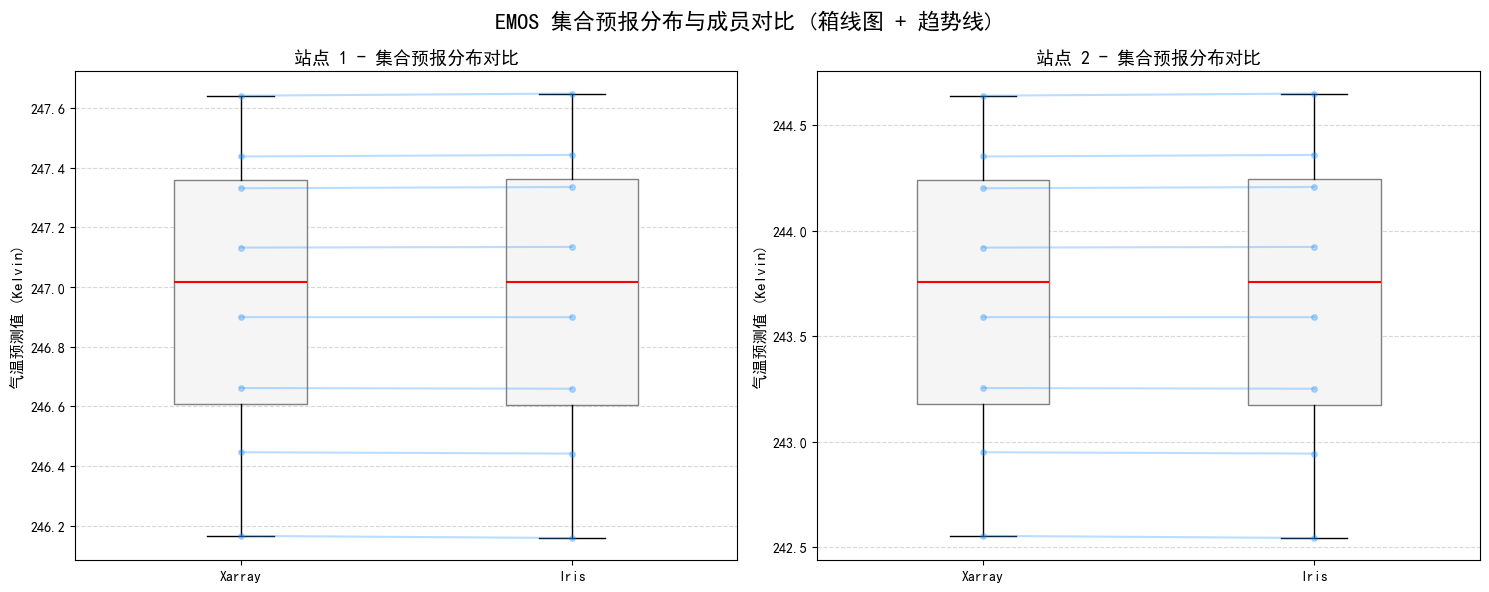

In [10]:
calibrated_prob_xr = applier_xr.process(forecast=apply_fc, coefficients=coeffs_xr, additional_fields=[dz_xr])
calibrated_prob_iris = applier_iris.process(apply_fc_iris, coefficients=coeffs_iris, additional_fields=dz_iris)

# 提取矩阵
matrix_xr = calibrated_prob_xr['air_temperature'].values
matrix_iris = calibrated_prob_iris.data

num_members = data_xr.shape[0]  # 51
x_indices = np.arange(num_members)  # 0 到 50 的成员索引

## --- 3. 创建 1行2列 的画布 (每个站点占一个子图) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

for site_idx in range(2):
    ax = axes[site_idx]

    val_xr = data_xr[:, site_idx]
    val_iris = data_iris[:, site_idx]

    # 1. 绘制箱线图展示整体分布区间
    # positions 设定箱子在横坐标的位置
    ax.boxplot(
        [val_xr, val_iris],
        positions=[1, 2],
        widths=0.4,
        patch_artist=True,
        boxprops=dict(facecolor="whitesmoke", color="gray"),
        medianprops=dict(color="red", linewidth=1.5),  # 红线为中位数
        labels=["Xarray", "Iris"],
    )

    # 2. 绘制 51 个成员的对应连线（看微观差异）
    # 横坐标 1 代表 Xarray，2 代表 Iris，把它们用透明灰色线连起来
    for member_idx in range(len(val_xr)):
        ax.plot(
            [1, 2],
            [val_xr[member_idx], val_iris[member_idx]],
            color="dodgerblue",
            alpha=0.3,
            marker="o",
            markersize=4,
        )

    # 子图细节设置
    ax.set_title(f"站点 {site_idx + 1} - 集合预报分布对比", fontsize=13, fontweight="bold")
    ax.set_ylabel("气温预测值 (Kelvin)", fontsize=11)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.suptitle(
    "EMOS 集合预报分布与成员对比 (箱线图 + 趋势线)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()
